In [12]:
%pip install -U -q numpy pandas wfdb matplotlib notebook scipy

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import wfdb
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from scipy import signal
from scipy.signal import butter, filtfilt, coherence, stft
import pywt


## Sekcja wczytwania


In [3]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis5'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

Rekord: charis5
Długość: 35999722 próbek (200.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


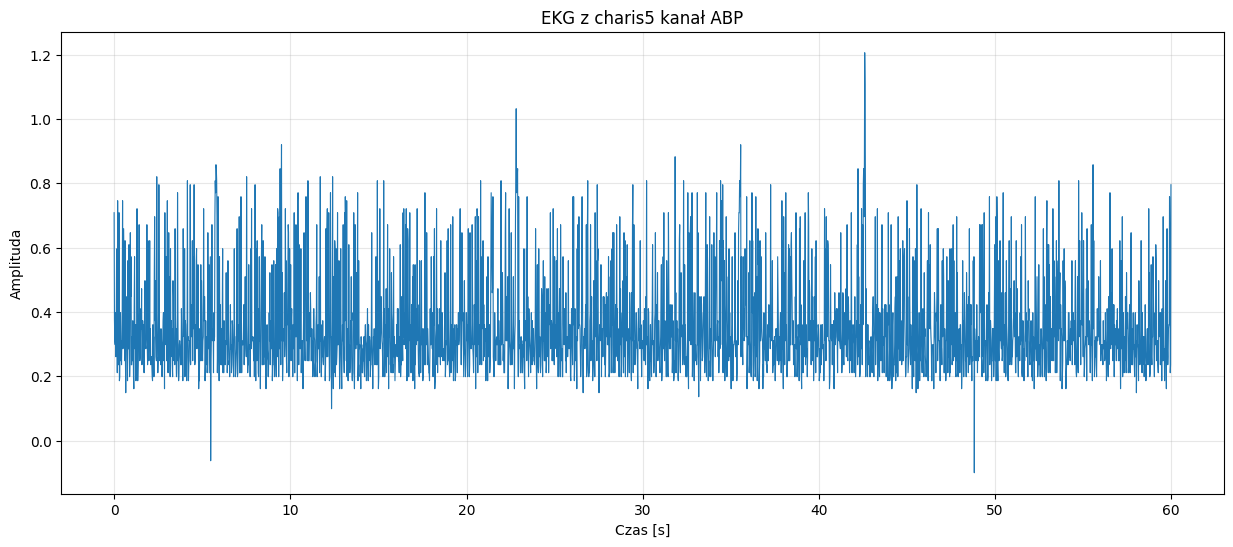

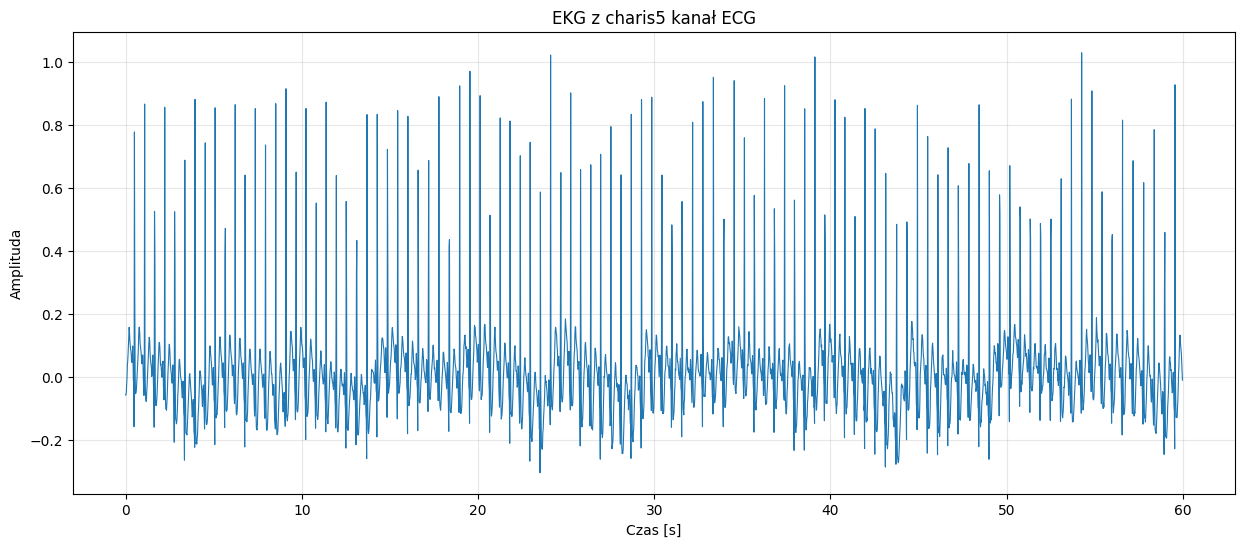

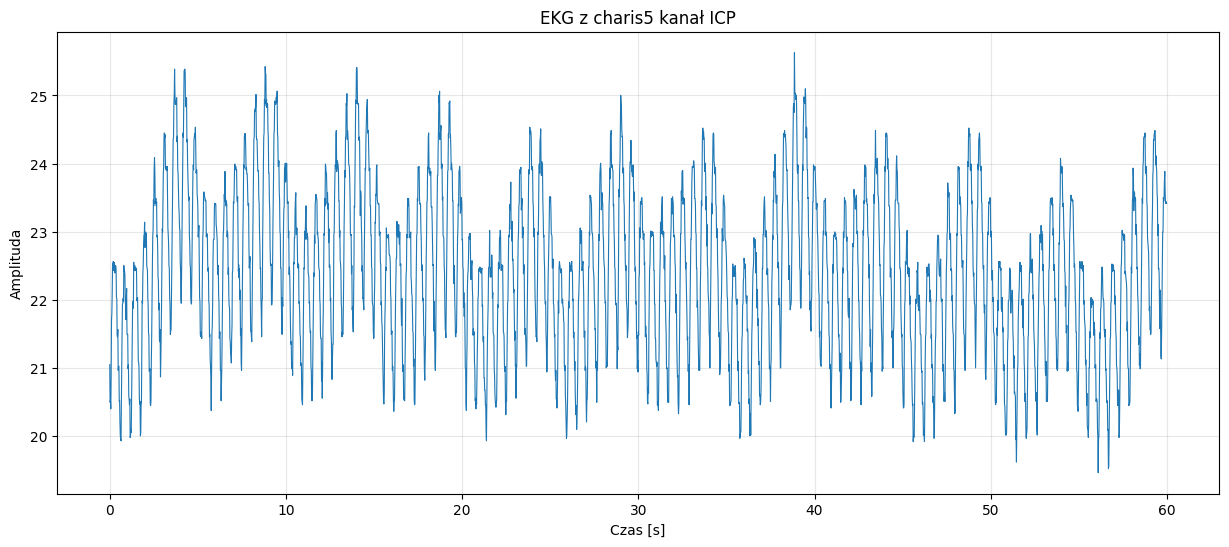

In [ ]:
# TERAZ TWÓJ KOD BEZ ZMIAN
local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # np. ['MCG', 'ABP', 'ICP']


# EKG/ECG (dostosuj indeks kanału)
for ecg_channel in range (0,3): # Lub 1 dla ECG w CHARIS
    ecg = signals[:, ecg_channel]
    abp = signals[:, 1]  # Ciśnienie krwi (w bazie CHARIS to zazwyczaj kanał 1)
    icp = signals[:, 2]  # Ciśnienie w mózgu (zazwyczaj kanał 2)

    # Wizualizacja pierwszych 60s
    plt.figure(figsize=(15, 6))
    plt.plot(time[:int(60*fs)], ecg[:int(60*fs)], linewidth=0.8)
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.title(f'EKG z {record_name} kanał {record.sig_name[ecg_channel]}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')


Rekord: charis1
Długość: 12239851 próbek (68.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


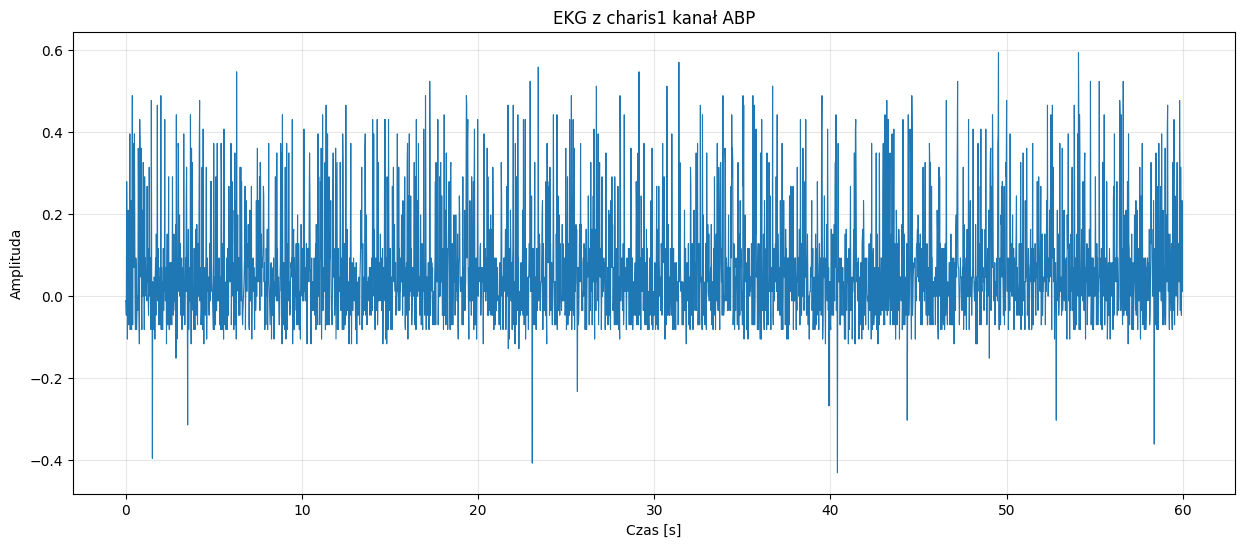

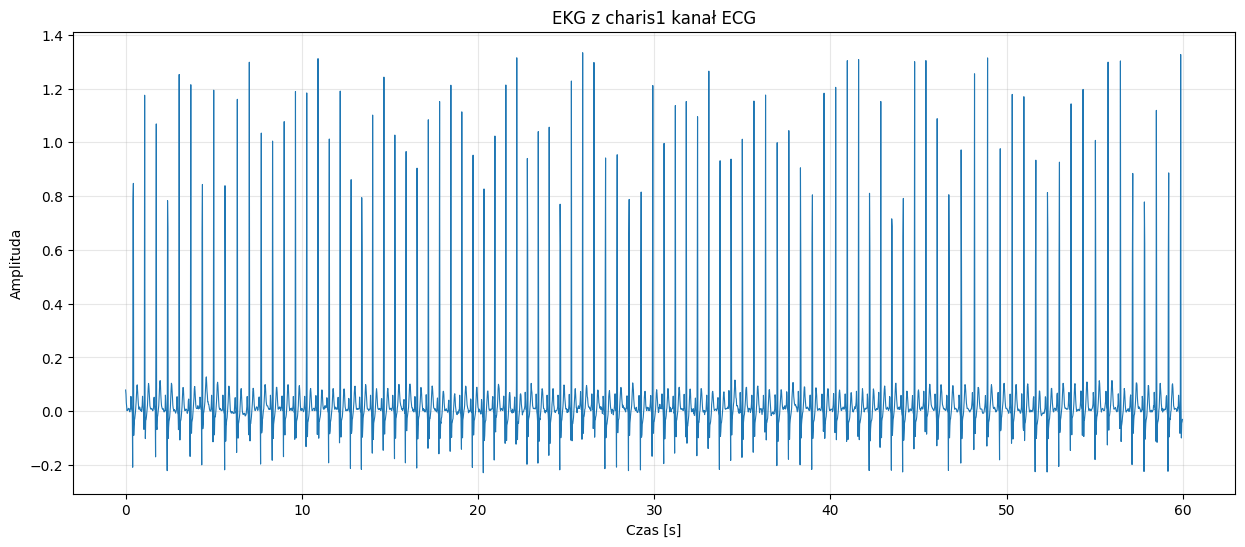

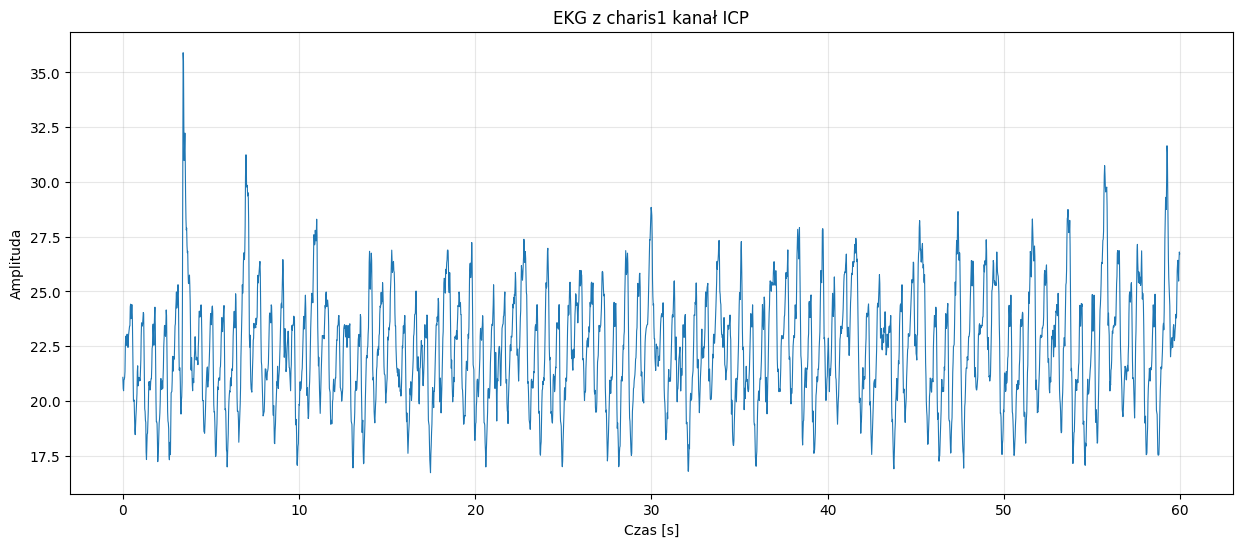

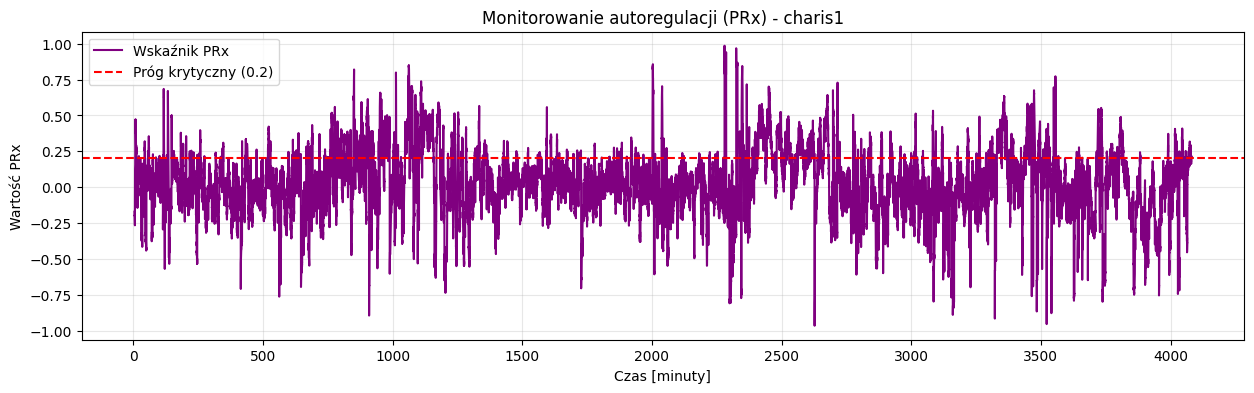

In [ ]:

import os
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis1'     # Nazwa rekordu (.hea i .dat)



os.makedirs(data_dir, exist_ok=True)

local_path = os.path.join(data_dir, record_name)

record = wfdb.rdrecord(local_path)
fs = record.fs  
signals = record.p_signal

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # np. ['MCG', 'ABP', 'ICP']

# EKG/ECG (dostosuj indeks kanału)
for ecg_channel in range (0,3): # Lub 1 dla ECG w CHARIS
    ecg = signals[:, ecg_channel]
    abp = signals[:, 1]  # Ciśnienie krwi (w bazie CHARIS to zazwyczaj kanał 1)
    icp = signals[:, 2]  # Ciśnienie w mózgu (zazwyczaj kanał 2)

    # Wizualizacja pierwszych 60s
    plt.figure(figsize=(15, 6))
    plt.plot(time[:int(60*fs)], ecg[:int(60*fs)], linewidth=0.8)
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.title(f'EKG z {record_name} kanał {record.sig_name[ecg_channel]}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')



# Bezpiecznik:
ecg = signals[:, 0]  # Kanał 0 to EKG
abp = signals[:, 1]  # Kanał 1 to ABP (ciśnienie krwi)
icp = signals[:, 2]  # Kanał 2 to ICP (ciśnienie wewnątrzczaszkowe)

# Wczytujemy rekord bezpośrednio tutaj
record = wfdb.rdrecord(local_path)
fs = float(record.fs)
signals = record.p_signal

# --- 2. FILTROWANIE (Zabezpieczone przed błędami matematycznymi) ---
nyq = 0.5 * fs

# Filtr dla ABP i ICP (10 Hz)
# np.clip pilnuje, żeby wartości nie wyszły poza zakres 0-1
cut_low = np.clip(10.0 / nyq, 0.001, 0.999)
b_lp, a_lp = signal.butter(4, cut_low, btype='low')
abp_czyste = signal.filtfilt(b_lp, a_lp, abp)
icp_czyste = signal.filtfilt(b_lp, a_lp, icp)

# Filtr dla EKG (0.5 - 40 Hz)
low_ecg = np.clip(0.5 / nyq, 0.001, 0.999)
high_ecg = np.clip(40.0 / nyq, 0.001, 0.999)

if low_ecg >= high_ecg:
    low_ecg = high_ecg * 0.1

b_ekg, a_ekg = signal.butter(4, [low_ecg, high_ecg], btype='bandpass')
ecg_czyste = signal.filtfilt(b_ekg, a_ekg, ecg)

# --- 3. WSKAŹNIK PRx (Analiza z artykułu) ---
okno_sekundy = 5
okno_probki = int(okno_sekundy * fs)
df = pd.DataFrame({'ABP': abp_czyste, 'ICP': icp_czyste})
df_srednie = df.groupby(df.index // okno_probki).mean()

# Korelacja ruchoma (5 minut = 60 okien po 5s)
prx = df_srednie['ICP'].rolling(window=60).corr(df_srednie['ABP'])
czas_prx = np.arange(len(prx)) * okno_sekundy / 60 

plt.figure(figsize=(15, 4))
plt.plot(czas_prx, prx, color='purple', label='Wskaźnik PRx')
plt.axhline(y=0.2, color='red', linestyle='--', label='Próg krytyczny (0.2)')
plt.xlabel('Czas [minuty]')
plt.ylabel('Wartość PRx')
plt.title(f'Monitorowanie autoregulacji (PRx) - {record_name}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

from scipy.signal import butter, filtfilt, coherence, stft

class SignalProcessor:
    def __init__(self, icp_data, abp_data, sampling_freq):
        # Inicjalizacja naszej klasy - wczytujemy surowe dane
        self.icp = np.array(icp_data)
        self.abp = np.array(abp_data)
        self.fs = sampling_freq  # częstotliwość próbkowania (ile pomiarów w sekundzie)

    def filtracja_sygnalow(self):
        # Tworzymy filtr pasmowoprzepustowy (przepuszcza od 0.02 Hz do 10 Hz)
        lowcut = 0.02
        highcut = 10.0 # Możesz tu zmienić na 20.0 zgodnie z tabelą
        nyq = 0.5 * self.fs
        low = lowcut / nyq
        high = highcut / nyq
        
        # Obliczamy parametry filtru
        b, a = butter(4, [low, high], btype='band')
        
        # Nakładamy filtr na sygnały (filtfilt nie przesuwa sygnału w czasie)
        self.icp = filtfilt(b, a, self.icp)
        self.abp = filtfilt(b, a, self.abp)
        print("Sygnały przefiltrowane.")

    def usun_szumy(self):
        # 1. Szumy ICP: Odrzucamy < -1 i > 100
        icp_mask_bad = (self.icp < -1) | (self.icp > 100)
        self.icp[icp_mask_bad] = np.nan # Zamieniamy błędy na "Brak Danych" (NaN)

        # 2. Szumy ABP: Poniżej 20 odrzucamy
        self.abp[self.abp < 20] = np.nan
        
        # Logika dla ABP > 200 przez więcej niż 2s jest trochę bardziej złożona 
        samples_in_2s = 2 * self.fs


        samples_in_05s = int(0.5 * self.fs)
        icp_diff = np.abs(np.append(np.zeros(samples_in_05s), self.icp[samples_in_05s:] - self.icp[:-samples_in_05s]))
        abp_diff = np.abs(np.append(np.zeros(samples_in_05s), self.abp[samples_in_05s:] - self.abp[:-samples_in_05s]))
        
        self.icp[icp_diff > 50] = np.nan
        self.abp[abp_diff > 50] = np.nan
        print("Szumy usunięte.")

    def packet_averaging(self, x_seconds):
        # Obliczamy średnią z każdych X sekund (MAP dla ABP, meanICP dla ICP)
        samples_per_packet = int(x_seconds * self.fs)
        
        # Tniemy tablice na kawałki i liczymy średnią pomijając wartości NaN
        # Użyjemy tu pandas dla wygody, bo super radzi sobie z oknami
        df = pd.DataFrame({'ICP': self.icp, 'ABP': self.abp})
        
        # Grupowanie co x_seconds i wyciąganie średniej
        averaged = df.groupby(np.arange(len(df)) // samples_per_packet).mean()
        
        self.mean_icp = averaged['ICP'].values
        self.map_abp = averaged['ABP'].values
        return self.mean_icp, self.map_abp

    def windowing(self, par_x):
        # Przesuwane okno (sliding window) - bierze X par średnich
        # Jeśli par_x to np. 10, bierzemy pierwsze 10, potem od 2 do 11, od 3 do 12 itd.
        okna_icp = np.lib.stride_tricks.sliding_window_view(self.mean_icp, window_shape=par_x)
        okna_abp = np.lib.stride_tricks.sliding_window_view(self.map_abp, window_shape=par_x)
        return okna_icp, okna_abp



def analiza_falkowa(sygnal, fs, skala_min=5, skala_max=20, krok=1):
    # Wykorzystuje transformację falkową (Morlet) 
    
    
    skale = np.arange(skala_min, skala_max + krok, krok)
    wspolczynniki, czestotliwosci = pywt.cwt(sygnal, skale, 'morlet')
    return wspolczynniki

def analiza_czasowo_czestotliwosciowa(sygnal, fs, rozmiar_okna=1024, overlap_percent=0.9):
    noverlap = int(rozmiar_okna * overlap_percent)
    
    f, t, Zxx = stft(sygnal, fs=fs, window='hann', nperseg=rozmiar_okna, noverlap=noverlap)
    

    pasmo_idx = np.argmin(np.abs(f - 0.4)) 
    wartosci_dla_04Hz = np.abs(Zxx[pasmo_idx, :])
    
    return t, wartosci_dla_04Hz

def analiza_koherencji(sygnal1, sygnal2, fs):
    # Badamy powiązanie między np. ICP a ABP
    f, Cxy = coherence(sygnal1, sygnal2, fs=fs)
    
    mask = (f >= 0.05) & (f <= 0.2)
    f_zainteresowania = f[mask]
    koherencja_w_pasmie = Cxy[mask]
    
    # Wartość graniczna to 0.5 (np. zwracamy tylko te momenty, gdzie jest powiązanie > 0.5)
    powiazane = koherencja_w_pasmie > 0.5
    
    return f_zainteresowania, koherencja_w_pasmie, powiazane

Rekord: charis2
Długość: 67499794 próbek (375.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


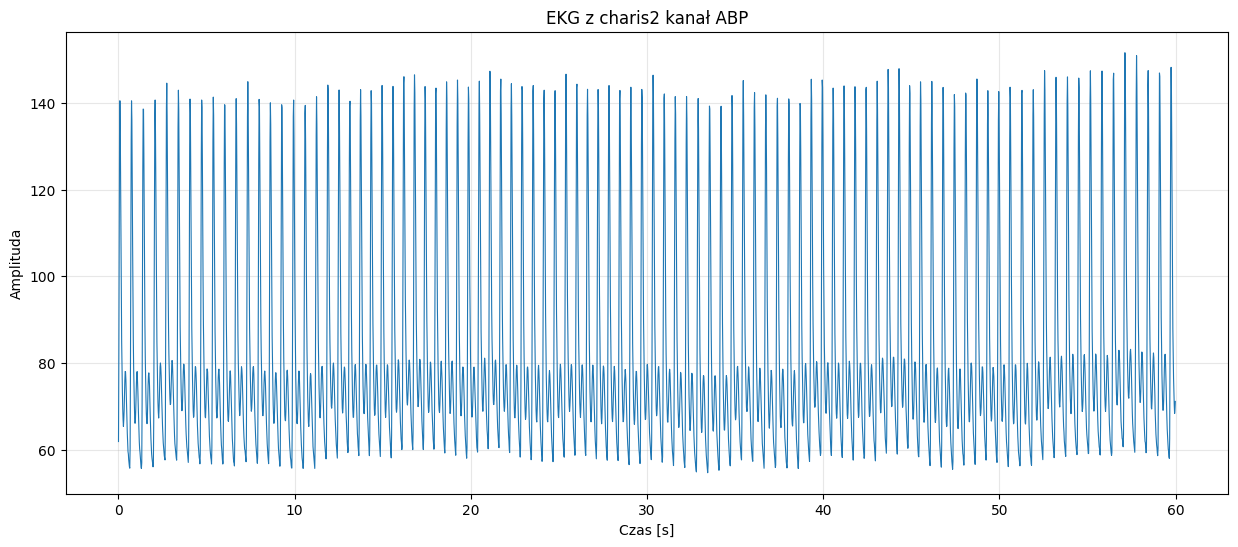

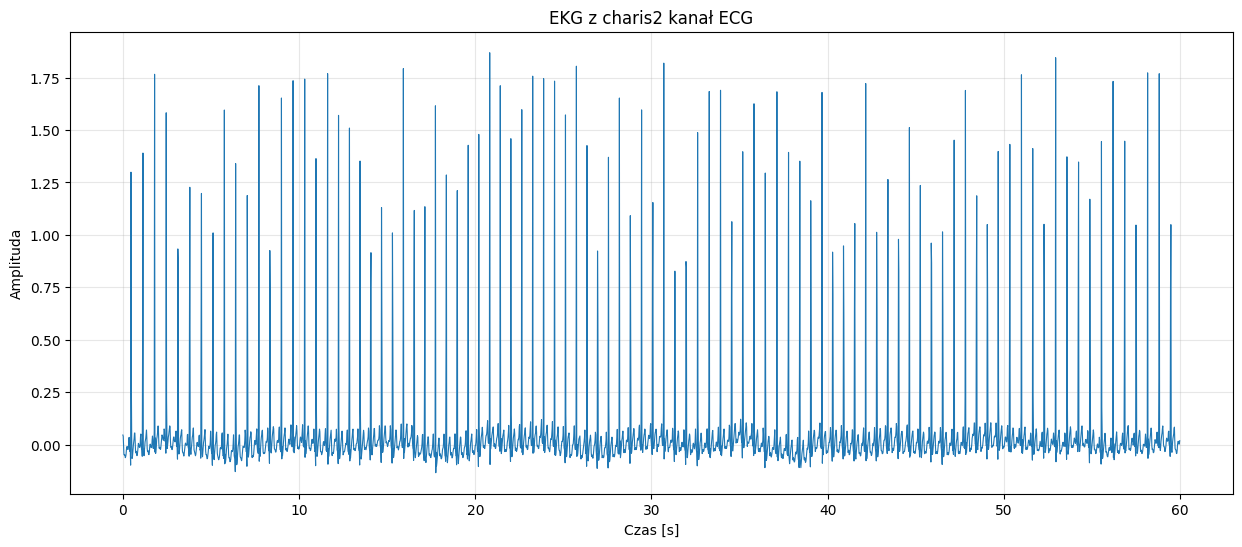

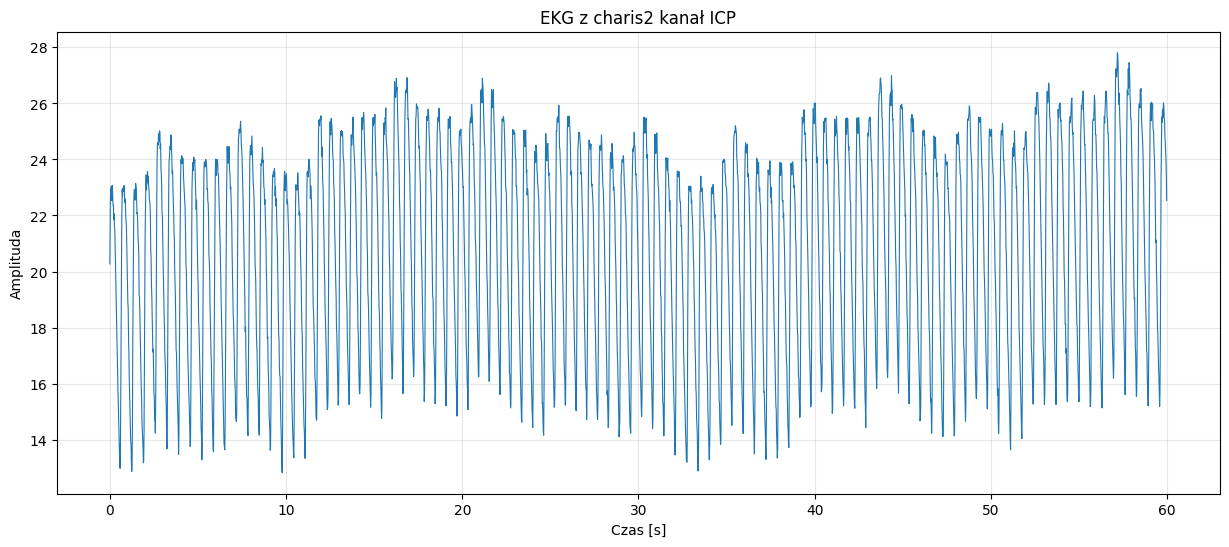

In [ ]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis2'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # np. ['MCG', 'ABP', 'ICP']

# EKG/ECG (dostosuj indeks kanału)
for ecg_channel in range (0,3): # Lub 1 dla ECG w CHARIS
    ecg = signals[:, ecg_channel]
    abp = signals[:, 1]  # Ciśnienie krwi (w bazie CHARIS to zazwyczaj kanał 1)
    icp = signals[:, 2]  # Ciśnienie w mózgu (zazwyczaj kanał 2)

    # Wizualizacja pierwszych 60s
    plt.figure(figsize=(15, 6))
    plt.plot(time[:int(60*fs)], ecg[:int(60*fs)], linewidth=0.8)
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.title(f'EKG z {record_name} kanał {record.sig_name[ecg_channel]}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')

Rekord: charis3
Długość: 17095224 próbek (95.0 h)
fs: 50 Hz, Kanały: 3
Nazwy kanałów: ['ABP', 'ECG', 'ICP']


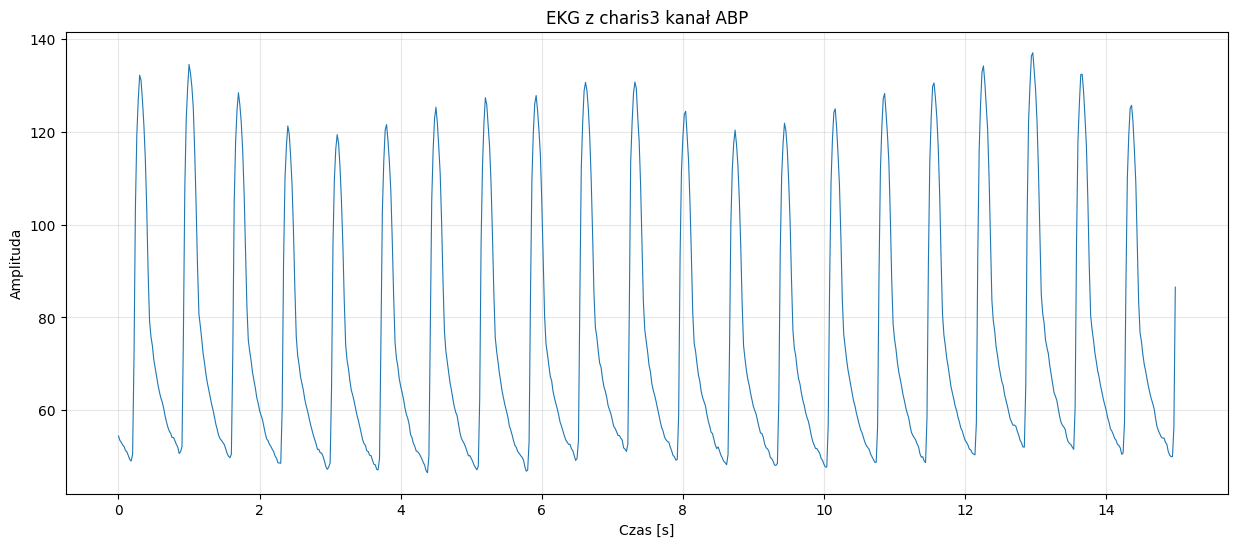

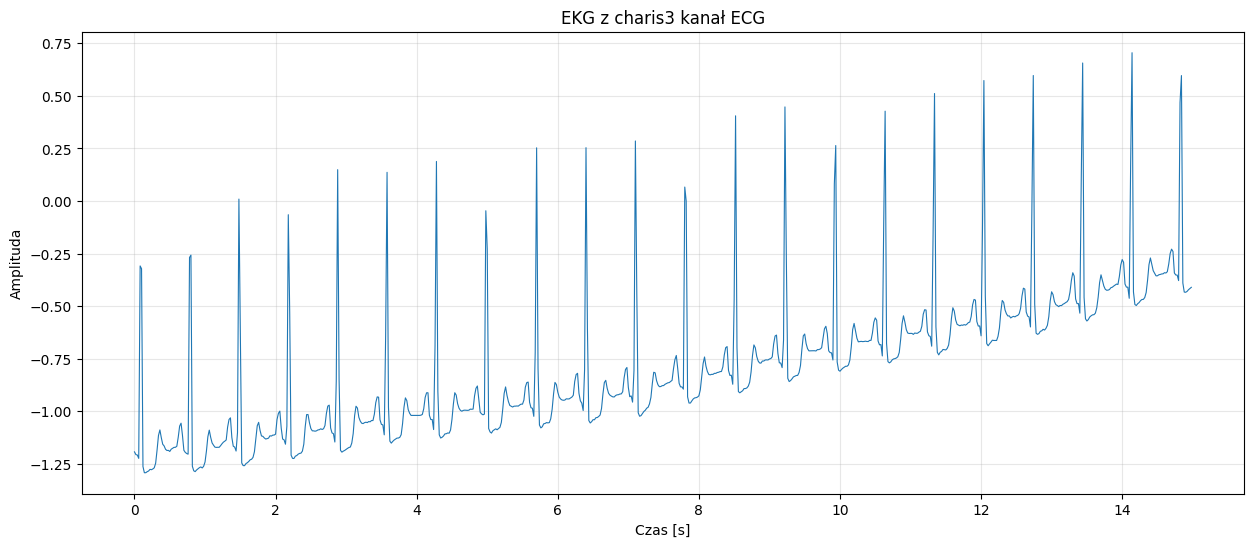

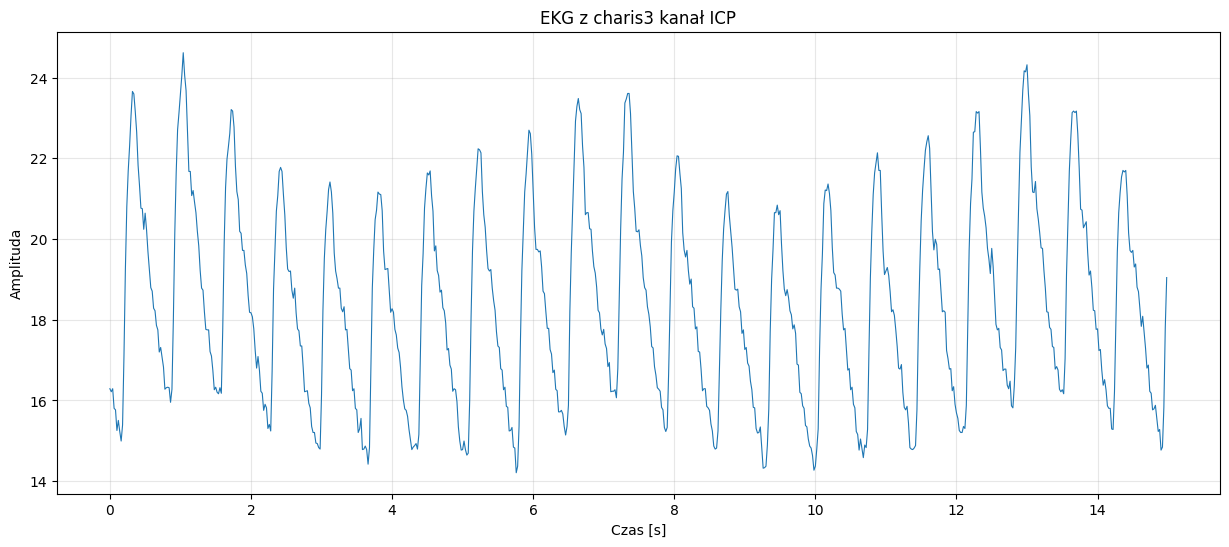

In [ ]:
data_dir = 'charis-database-1.0.0'  # Lokalny folder
record_name = 'charis3'     # Nazwa rekordu (.hea i .dat)

os.makedirs(data_dir, exist_ok=True)

local_path = os.path.join(data_dir, record_name)

# Odczyt (automatycznie znajdzie .hea i .dat)
record = wfdb.rdrecord(local_path)

# Dane sygnałów
signals = record.p_signal  # NxM tablica (próbki x kanały)
fs = record.fs  # Częstotliwość próbkowania
time = np.arange(len(signals)) / fs

print(f"Rekord: {record_name}")
print(f"Długość: {len(signals)} próbek ({len(signals)/fs/3600:.1f} h)")
print(f"fs: {fs} Hz, Kanały: {record.n_sig}")
print(f"Nazwy kanałów: {record.sig_name}")  # np. ['MCG', 'ABP', 'ICP']

# EKG/ECG (dostosuj indeks kanału)
for ecg_channel in range (0,3): # Lub 1 dla ECG w CHARIS
    ecg = signals[:, ecg_channel]
    abp = signals[:, 1]  # Ciśnienie krwi (w bazie CHARIS to zazwyczaj kanał 1)
    icp = signals[:, 2]  # Ciśnienie w mózgu (zazwyczaj kanał 2)

    # Wizualizacja pierwszych 60s
    plt.figure(figsize=(15, 6))
    plt.plot(time[:int(15*fs)], ecg[:int(15*fs)], linewidth=0.8)
    plt.xlabel('Czas [s]')
    plt.ylabel('Amplituda')
    plt.title(f'EKG z {record_name} kanał {record.sig_name[ecg_channel]}')
    plt.grid(True, alpha=0.3)
    plt.show()

# Zapis do CSV (opcjonalnie)
# np.savetxt('ecg_data.csv', np.column_stack([time, ecg]), delimiter=',', 
#            header='time_s,ecg_mv', comments='')